In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

In [3]:
sales = pd.read_csv("../scripts/sales.csv")
products = pd.read_csv("../scripts/products.csv")
stores = pd.read_csv("../scripts/stores.csv")

In [4]:
sales["sale_date"] = pd.to_datetime(sales["sale_date"])

sales = sales.merge(
    products,
    on="product_id"
)

sales = sales.merge(
    stores,
    on="store_id"
)

Top 10 Products

In [5]:
top_products = (
    sales.groupby("product_name")["quantity_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Coffee 25          199451
Tea 27             198934
Energy Drink 21    198842
Energy Drink 23    198633
Tea 28             198072
Tea 22             197929
Coffee 26          197679
Juice 24           197102
Juice 30           196895
Tea 29             196543
Name: quantity_sold, dtype: int64

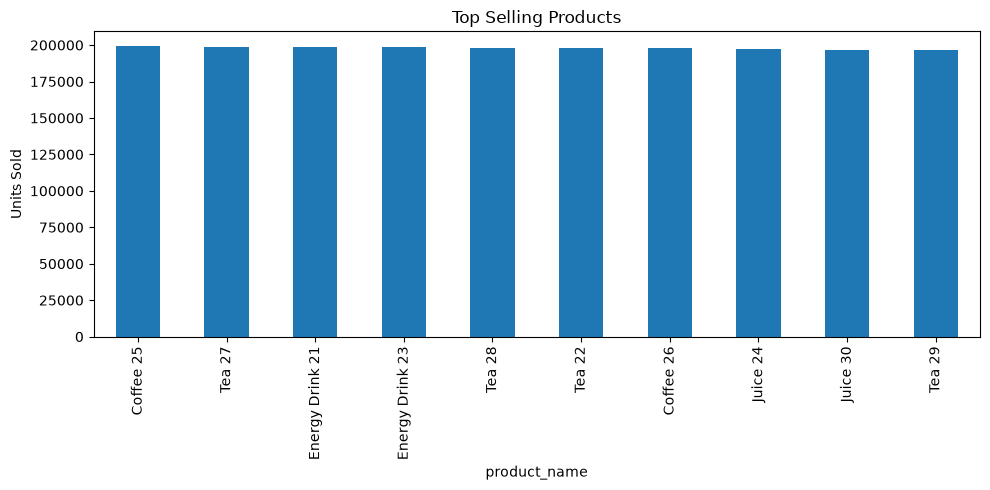

In [6]:
top_products.plot(kind="bar")

plt.title("Top Selling Products")

plt.ylabel("Units Sold")

plt.tight_layout()

plt.show()

Top Stores

In [7]:
top_stores = (
    sales.groupby("store_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_stores

store_name
Store_10    2.152396e+08
Store_7     2.152394e+08
Store_15    2.152234e+08
Store_9     2.151801e+08
Store_17    2.151757e+08
Store_12    2.151232e+08
Store_18    2.150414e+08
Store_11    2.150363e+08
Store_2     2.149803e+08
Store_8     2.148091e+08
Store_4     2.147227e+08
Store_3     2.146796e+08
Store_19    2.146146e+08
Store_13    2.144700e+08
Store_6     2.143549e+08
Store_14    2.143424e+08
Store_1     2.141821e+08
Store_5     2.141200e+08
Store_16    2.140049e+08
Store_20    2.132940e+08
Name: revenue, dtype: float64

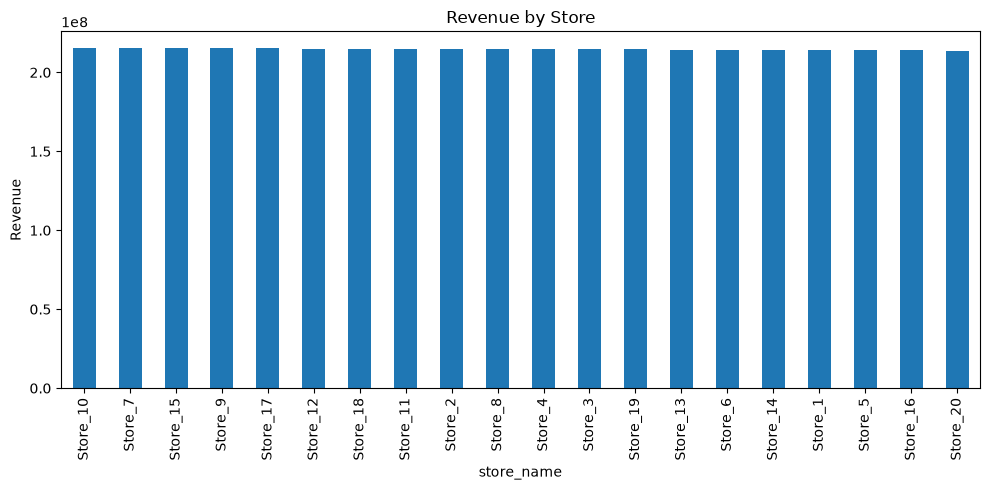

In [8]:
top_stores.plot(kind="bar")

plt.title("Revenue by Store")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

Category Analysis

In [9]:
category_sales = (
    sales.groupby("category")["quantity_sold"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

category
Beverages     1980080
Dairy         1885159
Frozen        1874833
Snacks        1852645
Bakery        1836633
Vegetables    1718401
Fruits        1717902
Grocery       1717550
Household     1716611
Meat          1713946
Name: quantity_sold, dtype: int64

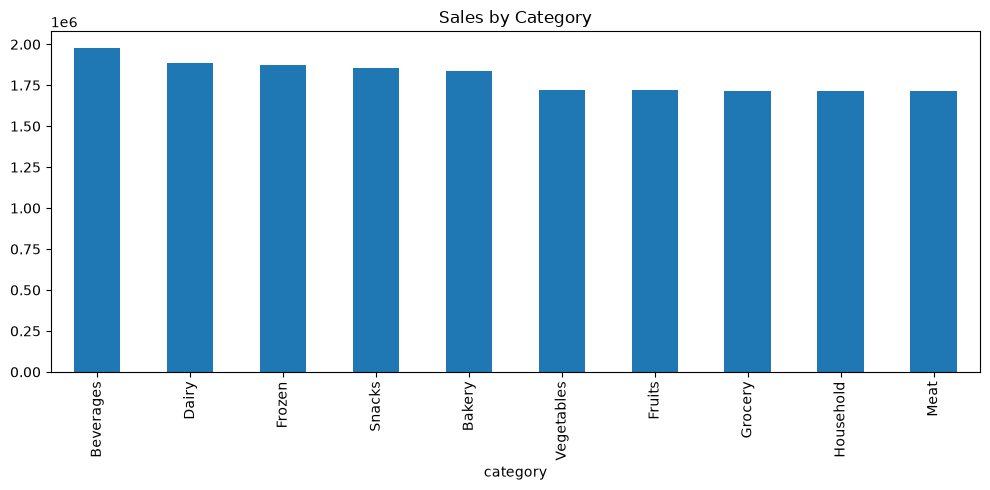

In [10]:
category_sales.plot(kind="bar")

plt.title("Sales by Category")

plt.tight_layout()

plt.show()

Monthly Sales

In [11]:
sales["month"] = sales["sale_date"].dt.month

monthly = (
    sales.groupby("month")["revenue"]
    .sum()
)

monthly

month
1     3.591885e+08
2     3.219640e+08
3     3.601672e+08
4     3.812551e+08
5     3.935461e+08
6     3.454542e+08
7     3.546726e+08
8     3.606339e+08
9     3.438680e+08
10    3.576699e+08
11    3.522121e+08
12    3.632021e+08
Name: revenue, dtype: float64

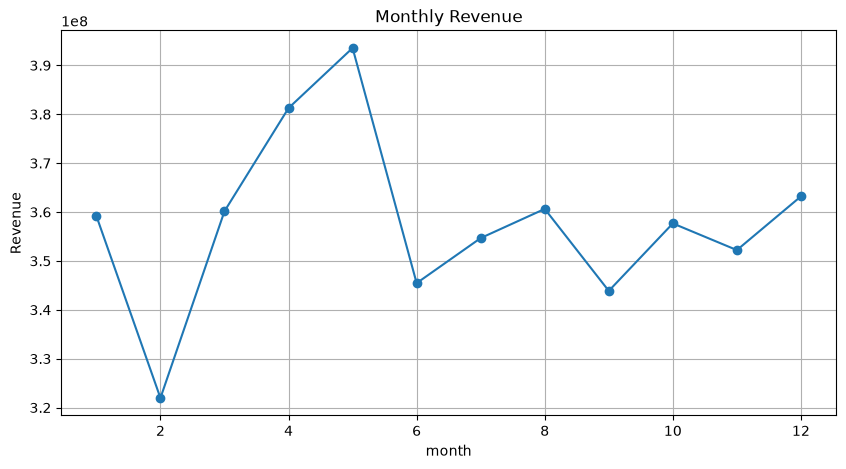

In [12]:
monthly.plot(marker="o")

plt.title("Monthly Revenue")

plt.ylabel("Revenue")

plt.grid()

plt.show()

Weekend Analysis

In [13]:
sales["weekend"] = (
    sales["sale_date"]
    .dt.dayofweek >= 5
)

In [14]:
weekend = (
    sales.groupby("weekend")["quantity_sold"]
    .mean()
)

weekend

weekend
False    24.007648
True     26.354654
Name: quantity_sold, dtype: float64

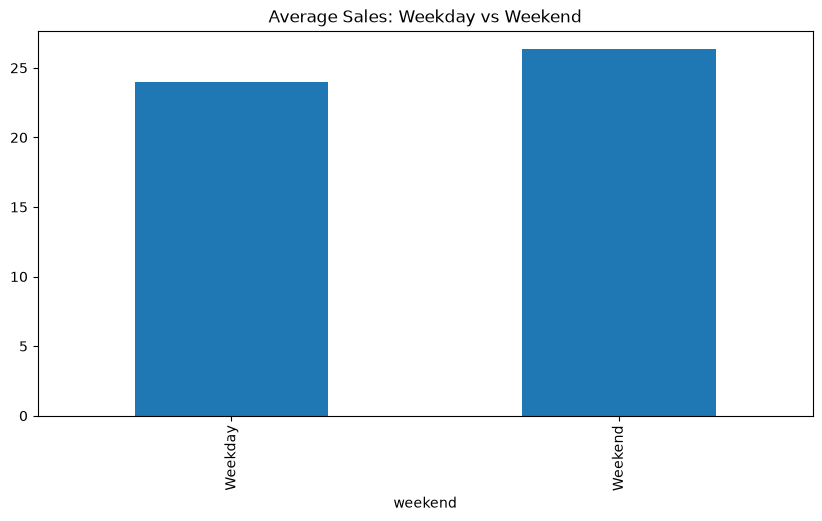

In [15]:
weekend.plot(kind="bar")

plt.title("Average Sales: Weekday vs Weekend")

plt.xticks([0,1],["Weekday","Weekend"])

plt.show()

Top Cities

In [16]:
city = (
    sales.groupby("city")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

city

city
Pune         8.599329e+08
Mysore       8.589893e+08
Hubli        6.435138e+08
Bangalore    4.298459e+08
Chennai      4.293001e+08
Belgaum      4.283598e+08
Kochi        2.152396e+08
Hyderabad    2.144700e+08
Mumbai       2.141821e+08
Name: revenue, dtype: float64

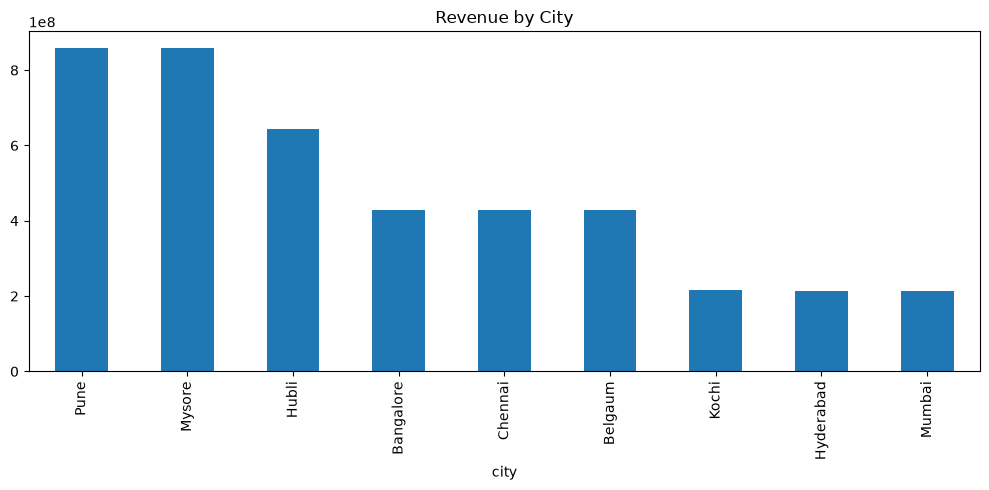

In [17]:
city.plot(kind="bar")

plt.title("Revenue by City")

plt.tight_layout()

plt.show()

Highest Revenue Products

In [18]:
revenue_products = (
    sales.groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

revenue_products

product_name
Tea 29             85131021.08
Frozen Pizza 68    82081205.12
Frozen Peas 64     81620296.24
Juice 24           80800785.64
Frozen Pizza 69    77326715.56
Apple 46           76935568.99
Oil 93             76811284.00
Milk 1             75217753.14
Mutton 59          74785622.78
Orange 49          74470381.18
Name: revenue, dtype: float64

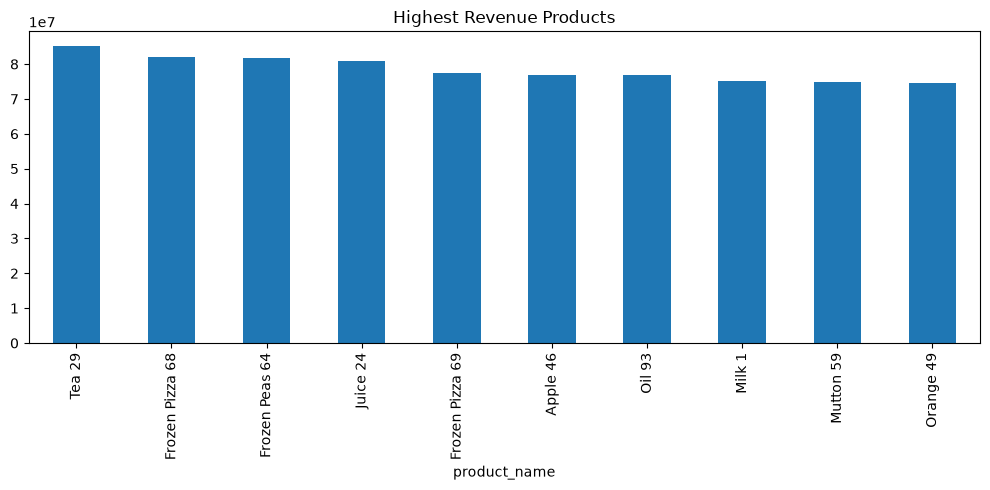

In [19]:
revenue_products.plot(kind="bar")

plt.title("Highest Revenue Products")

plt.tight_layout()

plt.show()

Business Insights

In [20]:
print("Business Insights")

print("-"*40)

print(f"Top Product : {top_products.index[0]}")

print(f"Top Store : {top_stores.index[0]}")

print(f"Top Category : {category_sales.index[0]}")

print(f"Top City : {city.index[0]}")

Business Insights
----------------------------------------
Top Product : Coffee 25
Top Store : Store_10
Top Category : Beverages
Top City : Pune


Save Summary

In [21]:
summary = pd.DataFrame({

    "Metric":[
        "Top Product",
        "Top Store",
        "Top Category",
        "Top City"
    ],

    "Value":[
        top_products.index[0],
        top_stores.index[0],
        category_sales.index[0],
        city.index[0]
    ]

})

summary.to_csv("../reports/eda_summary.csv",index=False)

summary

,Metric,Value
0,Top Product,Coffee 25
1,Top Store,Store_10
2,Top Category,Beverages
3,Top City,Pune
